In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [2]:
# ==============================
# STEP 1: Load data
# ==============================
df = pd.read_excel("data.xlsx")

print("\n===== HEAD =====")
print(df.head())

print("\n===== INFO =====")
print(df.info())

print("\n===== DESCRIBE =====")
print(df.describe())


===== HEAD =====
      WELL       DATE  HOURS    WHP   WHT       C2M        C3        C4  \
0  TFT-112 1999-03-05    NaN    NaN   0.0  0.000000  0.000000  0.000000   
1  TFT-301 1999-03-05    NaN    NaN   0.0  0.000000  0.000000  0.000000   
2  TFT-302 1999-03-05    0.0    0.0   0.0  0.000000  0.000000  0.000000   
3  TFT-302 1999-03-29    3.5  100.0  47.0  0.049894  0.002851  0.001703   
4  TFT-302 1999-04-01    8.3  100.0  53.0  0.113016  0.006513  0.003585   

        C5P       H2O     W_GAS     S_GAS    LPG_VOL   LPG_MASS   COND_VOL  \
0  0.000000  0.000000  0.000000  0.000000   0.000000   0.000000   0.000000   
1  0.000000  0.000000  0.000000  0.000000   0.000000   0.000000   0.000000   
2  0.000000  0.000000  0.000000  0.000000   0.000000   0.000000   0.000000   
3  0.001736  0.000106  0.056289  0.051875   9.062604   4.925386  11.448846   
4  0.004353  0.000286  0.127752  0.117394  22.517534  12.238639  24.612087   

   COND_MASS     WATER  prodindex  WLP  
0   0.000000  0.00000

In [ ]:
print("\n===== ROWS PER WELL =====")
print(df.groupby("WELL").size())

print("\n===== MISSING W_GAS =====")
print(df["W_GAS"].isna().sum())

print("\n===== MISSING DATE =====")
print(df["DATE"].isna().sum())

In [3]:
# ==============================
# STEP 2: Check missing values
# ==============================
print("\n===== MISSING VALUES =====")
print(df.isna().sum())


===== MISSING VALUES =====
WELL              0
DATE              0
HOURS            58
WHP              77
WHT              20
C2M               0
C3                0
C4                0
C5P               0
H2O               0
W_GAS             0
S_GAS             0
LPG_VOL           0
LPG_MASS          0
COND_VOL          0
COND_MASS         0
WATER             0
prodindex    536217
WLP          173843
dtype: int64


In [4]:
# STEP 3: Wells in dataset
# ==============================
print("\n===== UNIQUE WELLS =====")
print(df["WELL"].unique())

print("\nNumber of wells:", df["WELL"].nunique())


===== UNIQUE WELLS =====
<ArrowStringArray>
[  'TFT-112',   'TFT-301',   'TFT-302',   'TFT-303',   'TFT-304',   'TFT-305',
   'TFT-306',   'TFT-308',   'TFT-310',   'TFT-312',   'TFT-313',   'TFT-314',
   'TFT-315',   'TFT-316',   'TFT-317',   'TFT-318',   'TFT-319',   'TFT-320',
   'TFT-321',   'TFT-322',   'TFT-323',   'TFT-324',   'TFT-325',   'TFT-326',
   'TFT-327',  'TFT-329Z',   'TFT-330',   'TFT-331',   'TFT-332',  'TFT-333Z',
  'TFT-334Z',  'TFT-335Z',   'TFT-336',   'TFT-337',   'TFT-338',   'TFT-339',
   'TFT-340',  'TFT-341Z',   'TFT-342',   'TFT-343',   'TFT-344',   'TFT-345',
  'TFT-346Z',   'TFT-347',   'TFT-348',   'TFT-349',   'TFT-350',   'TFT-351',
   'TFT-352',   'TFT-353',   'TFT-354',   'TFT-355',   'TFT-356',   'TFT-357',
   'TFT-358',   'TFT-359',   'TFT-360',   'TFT-361',   'TFT-362',   'TFT-363',
   'TFT-364',   'TFT-365',   'TFT-366',   'TFT-367',   'TFT-368',   'TFT-369',
   'TFT-370',   'TFT-373',   'TFT-374',   'TFT-375',   'TFT-376',   'TFT-378',
   'TFT

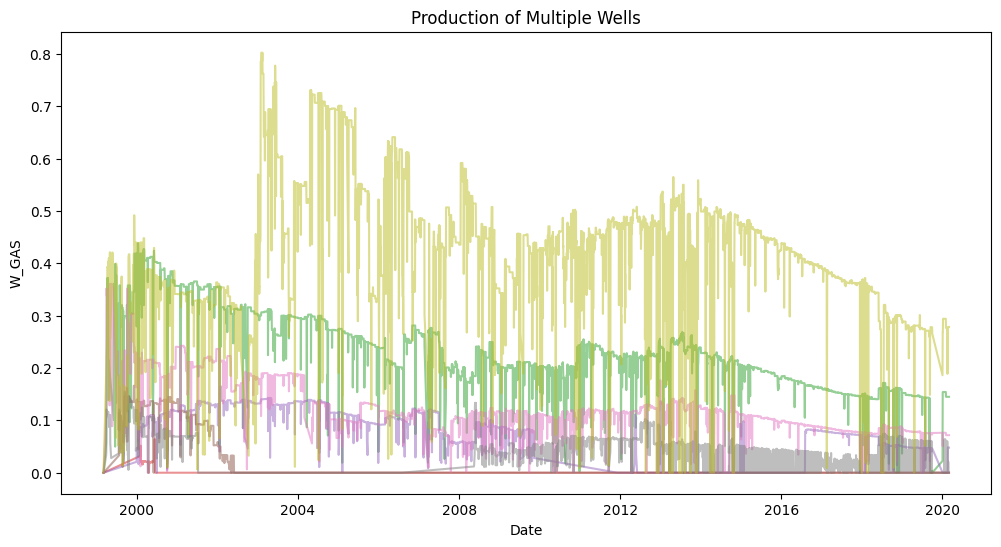

In [5]:
plt.figure(figsize=(12,6))

for well in df["WELL"].unique()[:10]:  # أول 10 فقط باش ما يتعمرش graph
    temp = df[df["WELL"] == well]
    temp = temp.sort_values("DATE")
    plt.plot(temp["DATE"], temp["W_GAS"], alpha=0.5)

plt.title("Production of Multiple Wells")
plt.xlabel("Date")
plt.ylabel("W_GAS")
plt.show()

<Figure size 1000x500 with 0 Axes>

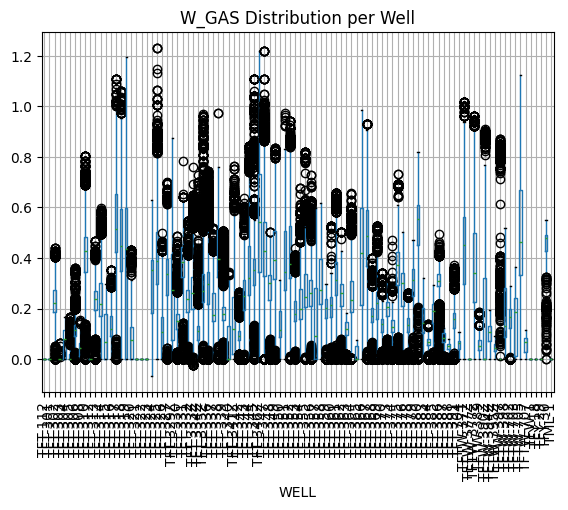

In [6]:
plt.figure(figsize=(10,5))

df.boxplot(column="W_GAS", by="WELL", rot=90)

plt.title("W_GAS Distribution per Well")
plt.suptitle("")
plt.show()

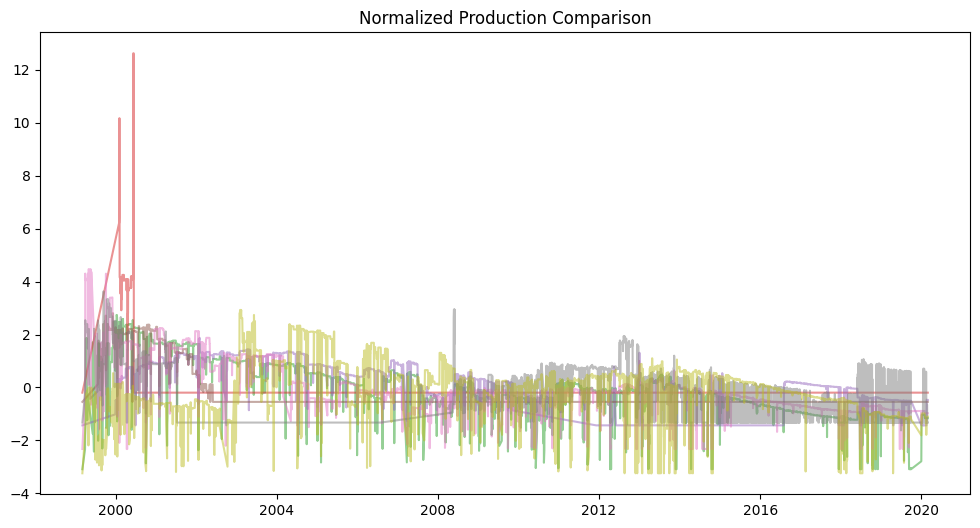

In [7]:
plt.figure(figsize=(12,6))

for well in df["WELL"].unique()[:10]:
    temp = df[df["WELL"] == well].sort_values("DATE")
    norm = (temp["W_GAS"] - temp["W_GAS"].mean()) / temp["W_GAS"].std()
    plt.plot(temp["DATE"], norm, alpha=0.5)

plt.title("Normalized Production Comparison")
plt.show()

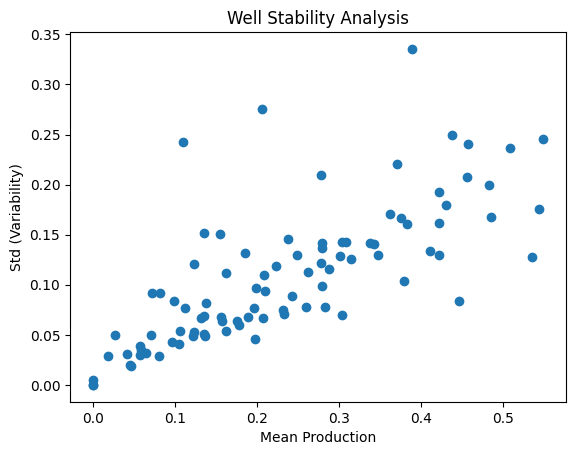

In [8]:
well_stats = df.groupby("WELL")["W_GAS"].agg(["mean", "std"])

plt.figure()
plt.scatter(well_stats["mean"], well_stats["std"])

plt.xlabel("Mean Production")
plt.ylabel("Std (Variability)")
plt.title("Well Stability Analysis")

plt.show()

In [9]:
corr_list = []

for well in df["WELL"].unique():
    temp = df[df["WELL"] == well]
    corr = temp[["W_GAS", "WHP", "WHT"]].corr().iloc[0,1:]
    
    corr_list.append({
        "WELL": well,
        "WHP_corr": corr["WHP"],
        "WHT_corr": corr["WHT"]
    })

corr_df = pd.DataFrame(corr_list)

print("\n===== CORRELATION PER WELL =====")
print(corr_df.head())


===== CORRELATION PER WELL =====
      WELL  WHP_corr  WHT_corr
0  TFT-112       NaN       NaN
1  TFT-301       NaN       NaN
2  TFT-302  0.756256  0.408431
3  TFT-303  0.920455  0.925762
4  TFT-304  0.896445  0.884309


In [19]:
baseline_list = []

for well in df["WELL"].unique():
    temp = df[df["WELL"] == well].sort_values("DATE")
    temp["lag1"] = temp["W_GAS"].shift(1)
    temp = temp.dropna()
    
    if len(temp) > 0:
        mae = mean_absolute_error(temp["W_GAS"], temp["lag1"])
        
        baseline_list.append({
            "WELL": well,
            "baseline_mae": mae
        })

baseline_df = pd.DataFrame(baseline_list)

print("\n===== BASELINE PER WELL =====")
print(baseline_df.head())


===== BASELINE PER WELL =====
Empty DataFrame
Columns: []
Index: []


In [18]:
plt.figure()
baseline_df["baseline_mae"].hist(bins=30)
plt.title("Baseline Error Distribution Across Wells")
plt.show()

KeyError: 'baseline_mae'

<Figure size 640x480 with 0 Axes>

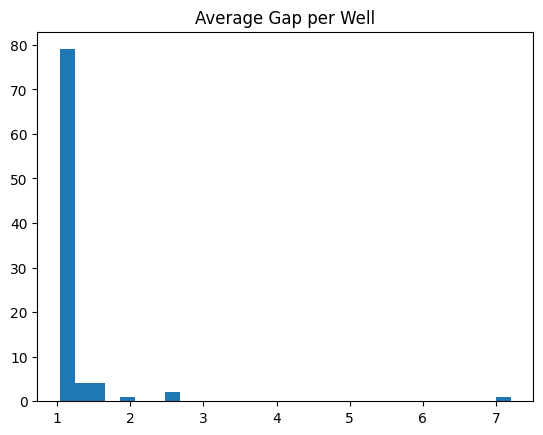

In [ ]:
gap_list = []

for well in df["WELL"].unique():
    temp = df[df["WELL"] == well].sort_values("DATE")
    temp["DELTA"] = temp["DATE"].diff().dt.days
    
    gap_list.append(temp["DELTA"].mean())

plt.figure()
plt.hist(gap_list, bins=30)
plt.title("Average Gap per Well")
plt.show()